In [1]:
import numpy as np
import pandas as pd
import uproot, awkward as ak
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve, roc_curve)
import xgboost as xgb
SEED = 42
np.random.seed(SEED)

In [2]:
# Loading Data
tuplename = '/Users/lamanazer/Downloads/DTT_Kmunu_small.root'
treename  = "DecayTree"
tree      = uproot.open(tuplename)[treename]
branches2 = ['Tr_AALLSAMEBPV', 'Tr_ACHI2DOCA', 'Tr_ADOCA', 'Tr_BPVIP', 'Tr_BPVIPCHI2','Tr_Charge', 'Tr_E', 'Tr_EcalE', 'Tr_Eta', 'Tr_HcalE', 'Tr_MinIP','Tr_MinIPChi2', 'Tr_ORIG_FLAGS', 'Tr_P', 'Tr_PIDK', 'Tr_PIDe', 'Tr_PIDmu',
    'Tr_PIDp', 'Tr_PROBNNe', 'Tr_PROBNNk', 'Tr_PROBNNmu', 'Tr_PROBNNp','Tr_PROBNNpi', 'Tr_PT', 'Tr_PZ', 'Tr_Phi', 'Tr_PrsE', 'Tr_THETA','Tr_TRCHI2DOF', 'Tr_TRFITMATCHCHI2', 'Tr_TRFITTCHI2','Tr_TRFITVELOCHI2NDOF', 'Tr_TRGHOSTPROB', 'Tr_TRTYPE',
    'Tr_TrFIRSTHITZ', 'Tr_TrFITTCHI2NDOF', 'Tr_VeloCharge',]
branches3 = branches2 + ["Tr_MC_ID"]
arr = tree.arrays(branches3, library="ak")
tracks = ak.zip({k: arr[k] for k in branches3})
flat = ak.flatten(tracks, axis=1)
df = pd.DataFrame({k: ak.to_numpy(flat[k]) for k in branches3})
ref = arr[branches3[0]]
evt = ak.local_index(ref, axis=0)
evt_idx_jagged = ak.broadcast_arrays(evt, ref)[0]
df["event_idx"] = ak.to_numpy(ak.flatten(evt_idx_jagged, axis=1))

In [3]:
#Labeling
y_trad = ((df["Tr_AALLSAMEBPV"] == 0) & (df["Tr_ORIG_FLAGS"] == 1)).astype(np.int8)
mc = pd.to_numeric(df["Tr_MC_ID"].astype("string"), errors="coerce") #processing Tr_MC_ID individually before adding to y definition
y_kaon = ((mc.abs() == 321) &(df["Tr_ORIG_FLAGS"] == 1) &(df["Tr_AALLSAMEBPV"] == 0)).astype(np.int8)
print(f"Dataset: {len(df):,} tracks "f"Trad positives: {y_trad.sum():,} ({y_trad.mean()*100:.2f}%) | "f"Kaon positives: {y_kaon.sum():,} ({y_kaon.mean()*100:.2f}%)")

#Features
drop = {"Tr_ORIG_FLAGS", "Tr_AALLSAMEBPV", "Tr_MC_ID", "event_idx"} #Monte Carlo truths 
feature_cols = [c for c in df.columns if c not in drop]
X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(np.int8)
groups = df["event_idx"].to_numpy()

Dataset: 11,566,653 tracks Trad positives: 821,253 (7.10%) | Kaon positives: 148,212 (1.28%)


In [ ]:
# Engineered features
X["pidk_x_probnnk"] = X["Tr_PIDK"].clip(-10, 50) * X["Tr_PROBNNk"].clip(0, 1) 
#PIDK is the log-likelihood difference between kaon and pion hypotheses from the RICH detector
#PROBNNk is a neural network kaon probability. Multiplying them means both must be high simultaneously 
X["kaon_vs_muon"]   = X["Tr_PIDK"] - X["Tr_PIDmu"].fillna(0) 
X["kaon_vs_proton"] = X["Tr_PIDK"] - X["Tr_PIDp"].fillna(0)
# how much more kaon-like is this track compared to muon or proton? A good kaon candidate should score high on PIDK but low on PIDmu and PIDp simultaneously
X["probnnk_ratio"]  = X["Tr_PROBNNk"] / (X["Tr_PROBNNpi"].fillna(0) + X["Tr_PROBNNk"] + 1e-9) #normalises PROBNNk against the pion probability
X["ip_x_probnnk"]   = X["Tr_BPVIPCHI2"].clip(0, 100) * X["Tr_PROBNNk"].clip(0, 1) 
# the feature above is only large when the track is both kaon-like and displaced from the primary vertex

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
def make_preprocessor():
    return ColumnTransformer(transformers=[("num", Pipeline([("imputer", SimpleImputer(strategy="median")),]), num_cols)],remainder="drop",)


In [5]:
# Cut based random baseline
cut_based = ((X["Tr_PIDK"].fillna(-999) > 0) &(X["Tr_PROBNNk"].fillna(0)  > 0.2)).astype(float).to_numpy()

#Bootstrap CI
def bootstrap_ci(y_true, p_score, metric_fn, n_boot=1000, ci=0.95):
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = np.random.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], p_score[idx]))
    scores = np.array(scores)
    alpha  = (1 - ci) / 2
    return scores.mean(), np.percentile(scores, alpha * 100), np.percentile(scores, (1 - alpha) * 100)

In [27]:
#Cross validation training + evals 
def cv_fit_eval(X, y, groups, label, n_splits=5):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_roc, fold_pr = [], []
    oof_y, oof_p, oof_g = [], [], []
    print(f"  Cross-validation: {label}  ({n_splits} folds)")
    for fold, (tr_idx, te_idx) in enumerate(sgkf.split(X, y, groups=groups)):
        Xtr_f, Xte = X.iloc[tr_idx], X.iloc[te_idx]
        ytr_f, yte = y.iloc[tr_idx], y.iloc[te_idx]
        gtr_f, gte = groups[tr_idx], groups[te_idx]
        gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
        tr2, val  = next(gss_inner.split(Xtr_f, ytr_f, groups=gtr_f))
        Xtr, Xval = Xtr_f.iloc[tr2], Xtr_f.iloc[val]
        ytr, yval = ytr_f.iloc[tr2], ytr_f.iloc[val]
        pre    = make_preprocessor()
        Xtr_p  = pre.fit_transform(Xtr)
        Xval_p = pre.transform(Xval)
        Xte_p  = pre.transform(Xte)
        neg, pos = (ytr == 0).sum(), (ytr == 1).sum()
        spw = neg / pos if pos > 0 else 1.0

        clf = xgb.XGBClassifier(n_estimators=3000, learning_rate=0.03,max_depth=5, subsample=0.8, colsample_bytree=0.8,reg_lambda=3.0, reg_alpha=1.0, min_child_weight=4.0, gamma=0.5,objective="binary:logistic", eval_metric="aucpr",tree_method="hist", n_jobs=4,scale_pos_weight=spw, random_state=SEED, early_stopping_rounds=100,)
        clf.fit(Xtr_p, ytr, eval_set=[(Xval_p, yval)], verbose=False)
        cal = CalibratedClassifierCV(clf, method="isotonic", cv="prefit")
        cal.fit(Xval_p, yval)
        p_te = cal.predict_proba(Xte_p)[:, 1]
        roc = roc_auc_score(yte, p_te)
        pr  = average_precision_score(yte, p_te)
        fold_roc.append(roc)
        fold_pr.append(pr)
        oof_y.append(yte.to_numpy())
        oof_p.append(p_te)
        oof_g.append(gte)
        print(f"  Fold {fold+1}: ROC={roc:.4f}  PR={pr:.4f}  "f"(best iter={clf.best_iteration})")
    fold_roc  = np.array(fold_roc)
    fold_pr   = np.array(fold_pr)
    oof_y_all = np.concatenate(oof_y)
    oof_p_all = np.concatenate(oof_p)
    oof_g_all = np.concatenate(oof_g)
    print(f"\n  ROC AUC: {fold_roc.mean():.4f} ± {fold_roc.std():.4f}")
    print(f"  PR  AUC: {fold_pr.mean():.4f}  ± {fold_pr.std():.4f}")
    print(f"  baseline: {y.mean():.4f}  |  lift: {fold_pr.mean()/y.mean():.1f}x")

    return fold_roc, fold_pr, oof_y_all, oof_p_all, oof_g_all
roc_trad, pr_trad, oof_y_trad, oof_p_trad, oof_g_trad = cv_fit_eval(X, y_trad, groups, label="Traditional")
roc_kaon, pr_kaon, oof_y_kaon, oof_p_kaon, oof_g_kaon = cv_fit_eval(X, y_kaon, groups, label="Kaon")


  Cross-validation: Traditional  (5 folds)
  Fold 1: ROC=0.6775  PR=0.1273  (best iter=2999)
  Fold 2: ROC=0.6817  PR=0.1282  (best iter=2996)
  Fold 3: ROC=0.6824  PR=0.1295  (best iter=2998)
  Fold 4: ROC=0.6823  PR=0.1294  (best iter=2997)
  Fold 5: ROC=0.6842  PR=0.1295  (best iter=2999)

  ROC AUC: 0.6816 ± 0.0022
  PR  AUC: 0.1288  ± 0.0009
  baseline: 0.0710  |  lift: 1.8x
  Cross-validation: Kaon  (5 folds)
  Fold 1: ROC=0.9109  PR=0.1316  (best iter=2947)
  Fold 2: ROC=0.9118  PR=0.1304  (best iter=2995)
  Fold 3: ROC=0.9121  PR=0.1305  (best iter=2994)
  Fold 4: ROC=0.9124  PR=0.1292  (best iter=2992)
  Fold 5: ROC=0.9120  PR=0.1341  (best iter=2998)

  ROC AUC: 0.9118 ± 0.0005
  PR  AUC: 0.1311  ± 0.0017
  baseline: 0.0128  |  lift: 10.2x


In [8]:
#Statistical significance
t_roc, p_roc = stats.ttest_rel(roc_kaon, roc_trad)
t_pr,  p_pr  = stats.ttest_rel(pr_kaon,  pr_trad)
print("\n Paired t-test (Kaon vs Traditional across folds)")
print(f"  ROC AUC: t={t_roc:.3f}, p={p_roc:.4f}  "f"{' significant' if p_roc < 0.05 else ' not significant'} at α=0.05")
print(f"  PR  AUC: t={t_pr:.3f},  p={p_pr:.4f}  "f"{' significant' if p_pr  < 0.05 else ' not significant'} at α=0.05")
#Bootstrap CI on prediciations from out of fold
print("\n Bootstrap 95% CI on OOF predictions")
for oof_y, oof_p, lbl in [(oof_y_trad, oof_p_trad, "Traditional"),(oof_y_kaon, oof_p_kaon, "Kaon"),]:
    roc_m, roc_lo, roc_hi = bootstrap_ci(oof_y, oof_p, roc_auc_score)
    pr_m,  pr_lo,  pr_hi  = bootstrap_ci(oof_y, oof_p, average_precision_score)
    baseline = oof_y.mean()
    print(f"\n  {lbl}:")
    print(f"    ROC AUC: {roc_m:.4f} [{roc_lo:.4f}, {roc_hi:.4f}]")
    print(f"    PR  AUC: {pr_m:.4f}  [{pr_lo:.4f},  {pr_hi:.4f}]  "f"(baseline={baseline:.4f}, lift={pr_m/baseline:.1f}x)")


 Paired t-test (Kaon vs Traditional across folds)
  ROC AUC: t=252.098, p=0.0000   significant at α=0.05
  PR  AUC: t=2.507,  p=0.0663   not significant at α=0.05

 Bootstrap 95% CI on OOF predictions

  Traditional:
    ROC AUC: 0.6816 [0.6810, 0.6821]
    PR  AUC: 0.1299  [0.1294,  0.1304]  (baseline=0.0710, lift=1.8x)

  Kaon:
    ROC AUC: 0.9118 [0.9112, 0.9124]
    PR  AUC: 0.1336  [0.1323,  0.1350]  (baseline=0.0128, lift=10.4x)


In [9]:

#Cut based 
sgkf_ref = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_indices = np.concatenate([te_idx for _, te_idx in sgkf_ref.split(X, y_kaon, groups=groups)])
cut_oof = cut_based[oof_indices]
print("\n Cut-based baseline vs ML")
print(f"baseline (random):  {y_kaon.mean():.4f}")
for p_score, lbl in [(oof_p_kaon, "Kaon ML"),(oof_p_trad, "Trad ML"),(cut_oof,    "Cut-based (PIDK>0 & PROBNNk>0.2)"),]:
    roc = roc_auc_score(oof_y_kaon, p_score)
    pr  = average_precision_score(oof_y_kaon, p_score)
    print(f"  {lbl:<38}: ROC={roc:.4f}  PR={pr:.4f}  "f"lift={pr/y_kaon.mean():.1f}x")


 Cut-based baseline vs ML
baseline (random):  0.0128
  Kaon ML                               : ROC=0.9118  PR=0.1337  lift=10.4x
  Trad ML                               : ROC=0.5001  PR=0.0128  lift=1.0x
  Cut-based (PIDK>0 & PROBNNk>0.2)      : ROC=0.7996  PR=0.0480  lift=3.7x


In [10]:
#threshold optimization
def best_threshold(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    idx = np.argmax(f1s)
    return thr[idx], prec[idx], rec[idx], f1s[idx]

print("\n Optimal threshold")
for oof_y, oof_p, lbl in [(oof_y_trad, oof_p_trad, "Traditional"),(oof_y_kaon, oof_p_kaon, "Kaon"),]:
    thr, p_at, r_at, f1_at = best_threshold(oof_y, oof_p)
    print(f"  {lbl}: threshold={thr:.3f}  P={p_at:.3f}  R={r_at:.3f}  F1={f1_at:.3f}")


 Optimal threshold
  Traditional: threshold=0.096  P=0.123  R=0.457  F1=0.193
  Kaon: threshold=0.108  P=0.154  R=0.341  F1=0.212


In [14]:
#Event level track aggregation
def event_aggregate(y_track, p_track, g, top_k=3):
    df_e = pd.DataFrame({"g": g, "y": y_track, "p": p_track})
    strategies = {}
    # Max: highest-scoring track
    agg = df_e.groupby("g").agg(y_evt=("y", "max"), p_evt=("p", "max"))
    strategies["max"] = (agg.y_evt.to_numpy(), agg.p_evt.to_numpy())
    # Min: lowest-scoring track 
    agg = df_e.groupby("g").agg(y_evt=("y", "max"), p_evt=("p", "min"))
    strategies["min"] = (agg.y_evt.to_numpy(), agg.p_evt.to_numpy())
    # Mean: average of all track scores
    agg = df_e.groupby("g").agg(y_evt=("y", "max"), p_evt=("p", "mean"))
    strategies["mean"] = (agg.y_evt.to_numpy(), agg.p_evt.to_numpy())
    # Sum normalised by sqrt(n_tracks)
    agg    = df_e.groupby("g").agg(y_evt=("y", "max"), p_evt=("p", "sum"))
    n_trk  = df_e.groupby("g")["p"].count()
    strategies["sum_norm"] = (agg.y_evt.to_numpy(), (agg.p_evt / np.sqrt(n_trk)).to_numpy())
    # Top-k mean
    def topk_mean(s): return s.nlargest(top_k).mean()
    agg_y    = df_e.groupby("g")["y"].max()
    agg_topk = df_e.groupby("g")["p"].apply(topk_mean)
    strategies[f"top{top_k}_mean"] = (agg_y.to_numpy(), agg_topk.to_numpy())
    # Top-k sum
    def topk_sum(s): return s.nlargest(top_k).sum()
    agg_topksum = df_e.groupby("g")["p"].apply(topk_sum)
    strategies[f"top{top_k}_sum"] = (agg_y.to_numpy(), agg_topksum.to_numpy())
    # Soft count: number of tracks above 0.5 threshold
    df_e["above_thr"] = (df_e["p"] > 0.5).astype(float)
    agg_soft = df_e.groupby("g").agg(y_evt=("y", "max"), p_evt=("above_thr", "sum"))
    strategies["soft_count"] = (agg_soft.y_evt.to_numpy(), agg_soft.p_evt.to_numpy())

    return strategies

In [15]:

# All strategies for both classifiers
strats_kaon = event_aggregate(oof_y_kaon, oof_p_kaon, oof_g_kaon)
strats_trad = event_aggregate(oof_y_trad, oof_p_trad, oof_g_trad)

In [16]:
# Select best strategy per classifier (by PR AUC)
def best_strategy(strats, y_col_idx=0, p_col_idx=1):
    best_name, best_pr = None, -1
    for name, (ye, pe) in strats.items():
        if len(np.unique(ye)) < 2:
            continue
        pr = average_precision_score(ye, pe)
        if pr > best_pr:
            best_pr   = pr
            best_name = name
    return best_name
best_kaon = best_strategy(strats_kaon)
best_trad = best_strategy(strats_trad)
print(f"\n Best aggregation strategy")
print(f"  Kaon ML  : {best_kaon}")
print(f"  Trad ML  : {best_trad}")
y_evt_kaon, p_evt_kaon = strats_kaon[best_kaon]
y_evt_trad, p_evt_trad = strats_trad[best_trad]


 Best aggregation strategy
  Kaon ML  : sum_norm
  Trad ML  : top3_sum


In [17]:
#prints best threshold
# Track level
for oof_y, oof_p, lbl in [(oof_y_trad, oof_p_trad, "Traditional (track)"),(oof_y_kaon, oof_p_kaon, "Kaon (track)"),]:
    thr, p_at, r_at, f1_at = best_threshold(oof_y, oof_p)
    print(f"{lbl}: threshold={thr:.3f} P={p_at:.3f} R={r_at:.3f} F1={f1_at:.3f}")

# Event level 
for ye, pe, lbl in [(y_evt_trad, p_evt_trad, f"Traditional (event/{best_trad})"),(y_evt_kaon, p_evt_kaon, f"Kaon (event/{best_kaon})"),]:
    thr, p_at, r_at, f1_at = best_threshold(ye, pe)
    print(f"{lbl}: threshold={thr:.3f}P={p_at:.3f} R={r_at:.3f} F1={f1_at:.3f}")

Traditional (track): threshold=0.096 P=0.123 R=0.457 F1=0.193
Kaon (track): threshold=0.108 P=0.154 R=0.341 F1=0.212
Traditional (event/top3_sum): threshold=0.143P=0.732 R=1.000 F1=0.845
Kaon (event/sum_norm): threshold=0.045P=0.432 R=0.917 F1=0.587


In [18]:
#Recall at fixed precision
def recall_at_precision(y_true, p, target):
    prec, rec, _ = precision_recall_curve(y_true, p)
    valid = np.where(prec[:-1] >= target)[0]
    return rec[valid].max() if len(valid) else None
print("\nRecall at fixed precision ")
print(f"{'Method':<38} {'P≥20%':>8} {'P≥50%':>8} {'P≥80%':>8}")
print("-" * 66)
for oof_y, oof_p, lbl in [(oof_y_kaon, oof_p_kaon, "Kaon ML"), (oof_y_trad, oof_p_trad, "Trad ML"),(oof_y_kaon, cut_oof,    "Cut-based"),]:
    rs = [recall_at_precision(oof_y, oof_p, t) for t in [0.20, 0.50, 0.80]]
    rs = [f"{v:.3f}" if v is not None else " N/A" for v in rs]
    print(f"  {lbl:<36} {rs[0]:>8} {rs[1]:>8} {rs[2]:>8}")


Recall at fixed precision 
Method                                    P≥20%    P≥50%    P≥80%
------------------------------------------------------------------
  Kaon ML                                 0.153    0.001      N/A
  Trad ML                                 0.058    0.001      N/A
  Cut-based                                 N/A      N/A      N/A


In [19]:
# Strategy comparison table 
print("\nEvent strategy comparison (Kaon ML)")
print(f"{'Strategy':<18} {'ROC AUC':>10} {'PR AUC':>10} {'Lift':>8}")
print(" " + "-" * 50)
for name, (ye, pe) in strats_kaon.items():
    if len(np.unique(ye)) < 2:
        continue
    roc = roc_auc_score(ye, pe)
    pr  = average_precision_score(ye, pe)
    tag = " ← best" if name == best_kaon else ""
    print(f"  {name:<18} {roc:>10.4f} {pr:>10.4f} {pr/ye.mean():>7.1f}x{tag}")

# Event-level metrics with bootstrap CI
print("\n Event-level metrics")
for ye, pe, lbl in [(y_evt_kaon, p_evt_kaon, f"Kaon ML ({best_kaon})"),(y_evt_trad, p_evt_trad, f"Trad ML ({best_trad})"),]:
    roc_m, roc_lo, roc_hi = bootstrap_ci(ye, pe, roc_auc_score)
    pr  = average_precision_score(ye, pe)
    print(f"  {lbl}: ROC={roc_m:.4f} [{roc_lo:.4f},{roc_hi:.4f}]"f"PR={pr:.4f}  lift={pr/ye.mean():.1f}x")



Event strategy comparison (Kaon ML)
Strategy              ROC AUC     PR AUC     Lift
 --------------------------------------------------
  max                    0.6118     0.4903     1.2x
  min                    0.4985     0.3984     1.0x
  mean                   0.6139     0.4956     1.2x
  sum_norm               0.6250     0.5061     1.3x ← best
  top3_mean              0.6240     0.5026     1.3x
  top3_sum               0.6239     0.5026     1.3x
  soft_count             0.5008     0.4003     1.0x

 Event-level metrics
  Kaon ML (sum_norm): ROC=0.6249 [0.6228,0.6270]PR=0.5061  lift=1.3x
  Trad ML (top3_sum): ROC=0.5554 [0.5530,0.5581]PR=0.7653  lift=1.0x


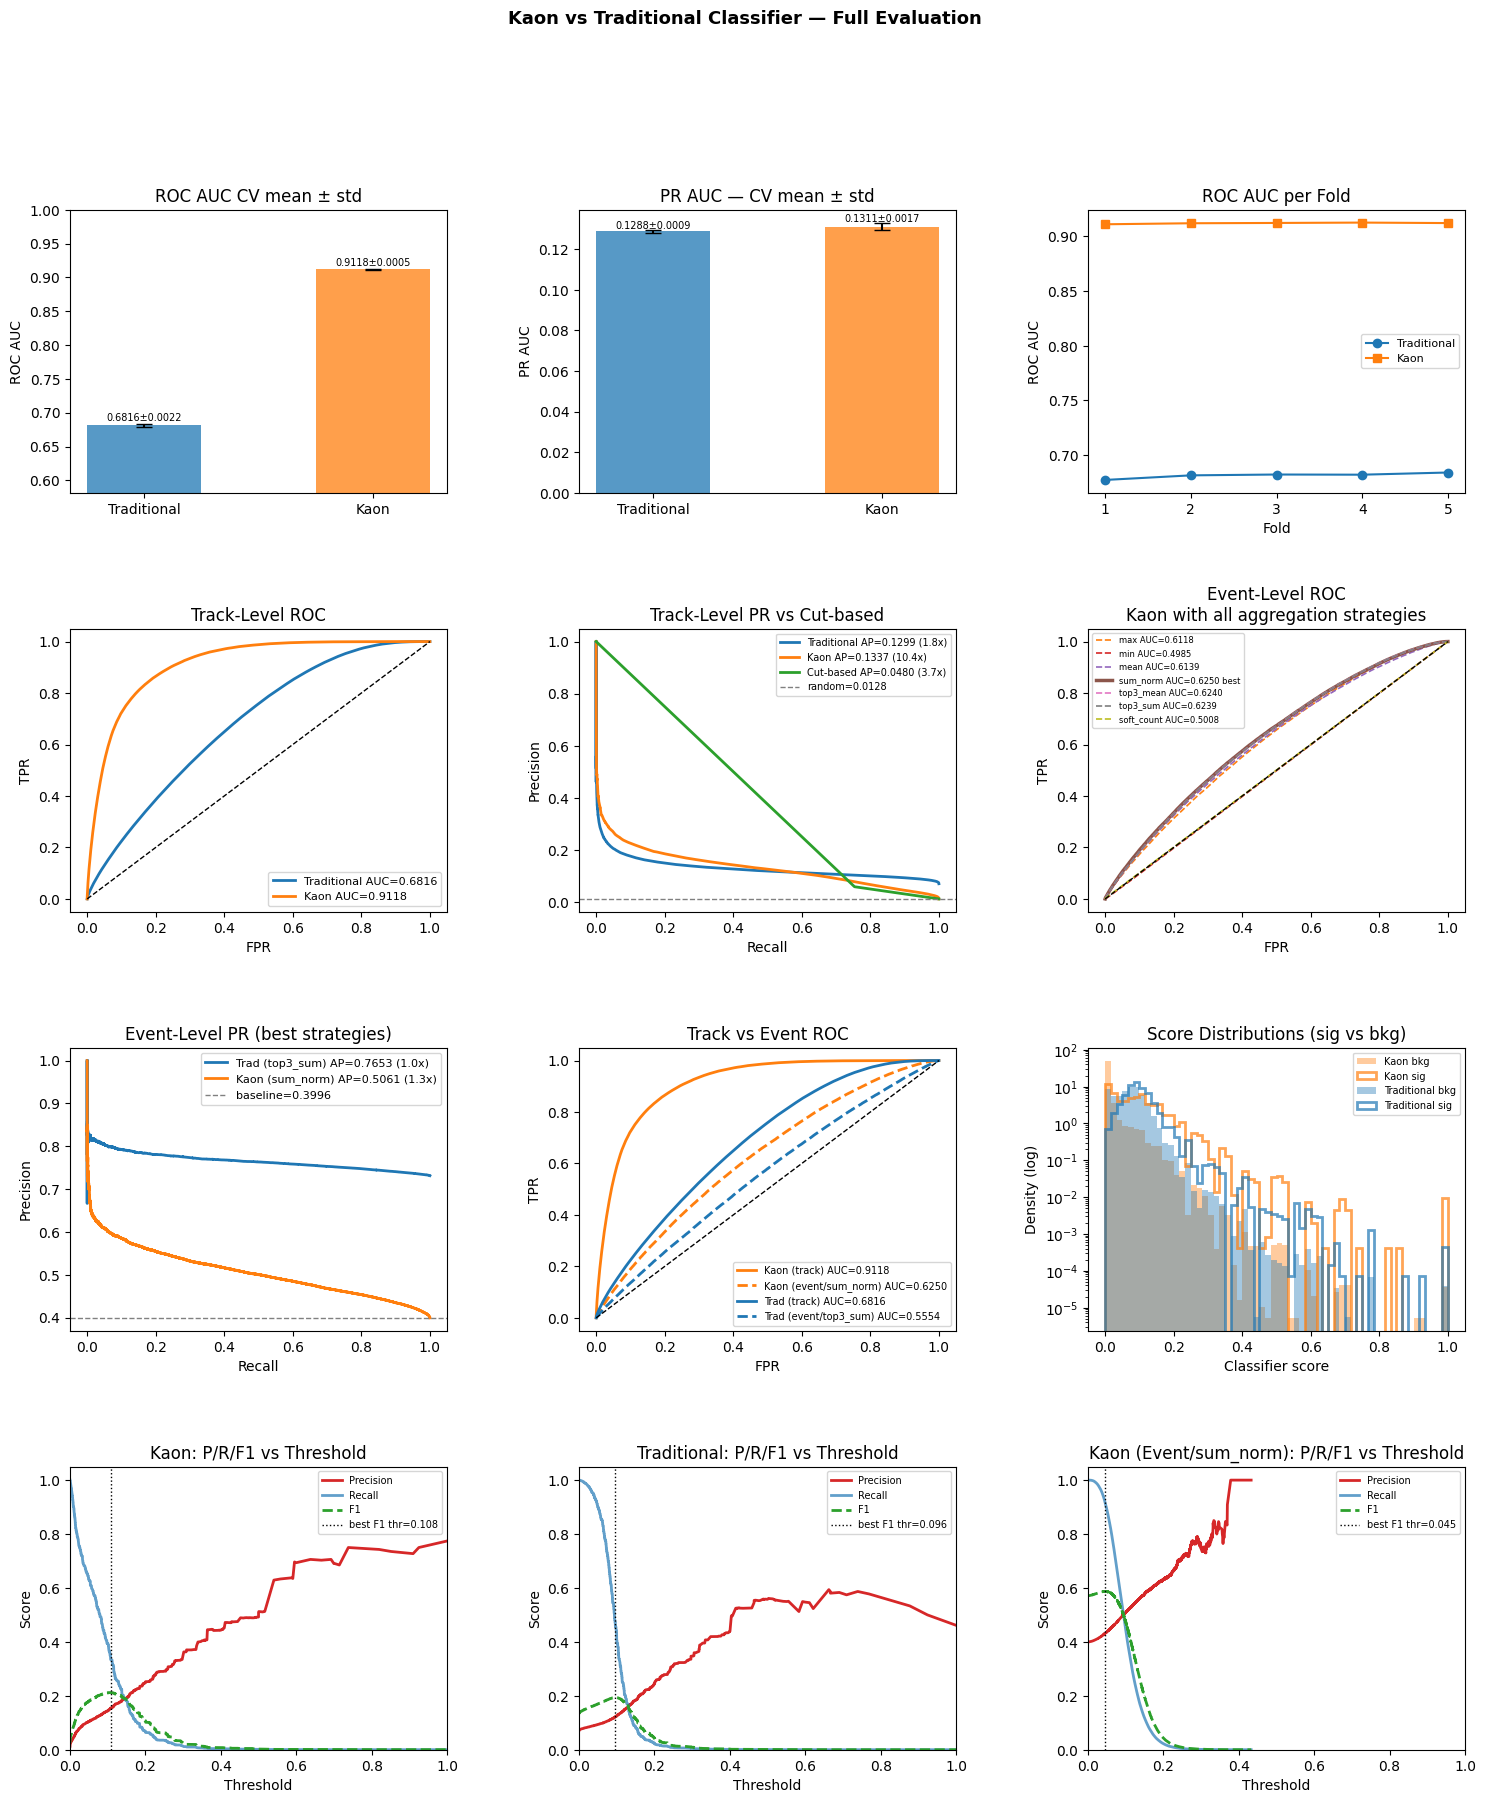


Saved: kaon_classifier_evaluation.pdf


In [21]:
#ALL plots
fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.35)

# CV ROC AUC bar
ax = fig.add_subplot(gs[0, 0])
x = np.array([1, 2])
means = np.array([roc_trad.mean(),roc_kaon.mean()])
stds = np.array([roc_trad.std(),roc_kaon.std()])
bars = ax.bar(x, means, yerr=stds, capsize=6,color=["tab:blue","tab:orange"], alpha=0.75, width=0.5)
ax.set_xticks(x); ax.set_xticklabels(["Traditional","Kaon"])
ax.set_ylabel("ROC AUC"); ax.set_title("ROC AUC CV mean ± std")
ax.set_ylim(max(0, means.min()-0.1), min(1, means.max()+0.1))
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.005,f"{m:.4f}±{s:.4f}", ha="center", fontsize=7)

# CV PR AUC bar 2
ax = fig.add_subplot(gs[0, 1])
means_pr = np.array([pr_trad.mean(), pr_kaon.mean()])
stds_pr  = np.array([pr_trad.std(),  pr_kaon.std()])
bars2    = ax.bar(x, means_pr, yerr=stds_pr, capsize=6, color=["tab:blue","tab:orange"], alpha=0.75, width=0.5)
ax.set_xticks(x); ax.set_xticklabels(["Traditional","Kaon"])
ax.set_ylabel("PR AUC"); ax.set_title("PR AUC — CV mean ± std")
for bar, m, s in zip(bars2, means_pr, stds_pr):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.0005,f"{m:.4f}±{s:.4f}", ha="center", fontsize=7)

# Fold by fold ROC stability
ax = fig.add_subplot(gs[0, 2])
folds = np.arange(1, len(roc_trad)+1)
ax.plot(folds, roc_trad, "o-", color="tab:blue",   label="Traditional")
ax.plot(folds, roc_kaon, "s-", color="tab:orange", label="Kaon")
ax.set_xlabel("Fold"); ax.set_ylabel("ROC AUC")
ax.set_title("ROC AUC per Fold")
ax.legend(fontsize=8); ax.set_xticks(folds)

# Track-level ROC
ax = fig.add_subplot(gs[1, 0])
for oof_y, oof_p, col, lbl in [(oof_y_trad, oof_p_trad, "tab:blue",   "Traditional"),(oof_y_kaon, oof_p_kaon, "tab:orange", "Kaon"),]:
    fpr, tpr, _ = roc_curve(oof_y, oof_p)
    auc = roc_auc_score(oof_y, oof_p)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{lbl} AUC={auc:.4f}")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Track-Level ROC")
ax.legend(fontsize=8)

# Track-level PR 
ax = fig.add_subplot(gs[1, 1])
for oof_y, oof_p, col, lbl in [(oof_y_trad, oof_p_trad, "tab:blue",   "Traditional"),(oof_y_kaon, oof_p_kaon, "tab:orange", "Kaon"),(oof_y_kaon, cut_oof,    "tab:green",  "Cut-based"),]:
    prec, rec, _ = precision_recall_curve(oof_y, oof_p)
    ap = average_precision_score(oof_y, oof_p)
    ax.plot(rec, prec, color=col, lw=2, label=f"{lbl} AP={ap:.4f} ({ap/oof_y.mean():.1f}x)")
ax.axhline(oof_y_kaon.mean(), color="gray", ls="--", lw=1, label=f"random={oof_y_kaon.mean():.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Track-Level PR vs Cut-based")
ax.legend(fontsize=7)

# Event-level ROC all aggregation strategies for Kaon
ax = fig.add_subplot(gs[1, 2])
colors_strat = ["tab:orange","tab:red","tab:purple","tab:brown","tab:pink","tab:gray","tab:olive"]
for (name, (ye, pe)), col in zip(strats_kaon.items(), colors_strat):
    if len(np.unique(ye)) < 2:
        continue
    fpr, tpr, _ = roc_curve(ye, pe)
    auc = roc_auc_score(ye, pe)
    lw  = 2.5 if name == best_kaon else 1.2
    ls  = "-"  if name == best_kaon else "--"
    label = f"{name} AUC={auc:.4f}" + (" best" if name == best_kaon else "")
    ax.plot(fpr, tpr, color=col, lw=lw, ls=ls, label=label)
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Event-Level ROC\nKaon with all aggregation strategies")
ax.legend(fontsize=6)

#Event PR 
ax = fig.add_subplot(gs[2, 0])
for ye, pe, col, lbl in [(y_evt_trad, p_evt_trad, "tab:blue",   f"Trad ({best_trad})"),(y_evt_kaon, p_evt_kaon, "tab:orange", f"Kaon ({best_kaon})"),]:
    prec, rec, _ = precision_recall_curve(ye, pe)
    ap = average_precision_score(ye, pe)
    ax.plot(rec, prec, color=col, lw=2,  label=f"{lbl} AP={ap:.4f} ({ap/ye.mean():.1f}x)")
ax.axhline(y_evt_kaon.mean(), color="gray", ls="--", lw=1,label=f"baseline={y_evt_kaon.mean():.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Event-Level PR (best strategies)")
ax.legend(fontsize=8)

#Track vs Event ROC comparison 
ax = fig.add_subplot(gs[2, 1])
for ye, pe, col, lbl, ls in [(oof_y_kaon, oof_p_kaon, "tab:orange", "Kaon (track)", "-"),(y_evt_kaon, p_evt_kaon, "tab:orange", f"Kaon (event/{best_kaon})", "--"),(oof_y_trad, oof_p_trad, "tab:blue",   "Trad (track)", "-"),(y_evt_trad, p_evt_trad, "tab:blue",   f"Trad (event/{best_trad})", "--"),]:
    fpr, tpr, _ = roc_curve(ye, pe)
    auc = roc_auc_score(ye, pe)
    ax.plot(fpr, tpr, color=col, lw=2, ls=ls, label=f"{lbl} AUC={auc:.4f}")
ax.plot([0,1],[0,1],"k--", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Track vs Event ROC")
ax.legend(fontsize=7)

#Score dist
ax = fig.add_subplot(gs[2, 2])
for oof_y, oof_p, col, lbl in [(oof_y_kaon, oof_p_kaon, 'tab:orange', 'Kaon'),(oof_y_trad, oof_p_trad, 'tab:blue', 'Traditional')]:
    ax.hist(oof_p[oof_y==0], bins=60,density=True, alpha=0.4,color=col, label=f"{lbl} bkg")
    ax.hist(oof_p[oof_y==1],bins=60, density=True, alpha=0.7, color=col, histtype="step", lw=2, label=f"{lbl} sig")
ax.set_xlabel("Classifier score")
ax.set_ylabel("Density (log)")
ax.set_title("Score Distributions (sig vs bkg)")
ax.set_yscale("log")
ax.legend(fontsize=7)

#  P/R/F1 vs Threshold — Kaon 
ax = fig.add_subplot(gs[3, 0])
prec, rec, thr = precision_recall_curve(oof_y_kaon, oof_p_kaon)
f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
ax.plot(thr, prec[:-1],lw=2, color="tab:red", label="Precision")
ax.plot(thr, rec[:-1],lw=2, color="tab:blue",label="Recall", alpha=0.7)
ax.plot(thr, f1s,lw=2, color="tab:green", ls="--", label="F1")
best_idx = np.argmax(f1s)
ax.axvline(thr[best_idx], color="black", lw=1, ls=":",label=f"best F1 thr={thr[best_idx]:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Kaon: P/R/F1 vs Threshold")
ax.legend(fontsize=7); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

# P/R/F1 vs Threshold — Traditional 
ax = fig.add_subplot(gs[3, 1])
prec, rec, thr = precision_recall_curve(oof_y_trad, oof_p_trad)
f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
ax.plot(thr, prec[:-1],lw=2, color="tab:red", label="Precision")
ax.plot(thr, rec[:-1],lw=2, color="tab:blue",label="Recall", alpha=0.7)
ax.plot(thr, f1s,lw=2, color="tab:green", ls="--", label="F1")
best_idx = np.argmax(f1s)
ax.axvline(thr[best_idx], color="black", lw=1, ls=":",label=f"best F1 thr={thr[best_idx]:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Traditional: P/R/F1 vs Threshold")
ax.legend(fontsize=7); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

# P/R/F1 vs Threshold — Kaon EVENT
ax = fig.add_subplot(gs[3, 2])
prec_e, rec_e, thr_e = precision_recall_curve(y_evt_kaon, p_evt_kaon)
f1s_e = 2*prec_e[:-1]*rec_e[:-1] / (prec_e[:-1]+rec_e[:-1]+1e-9)
ax.plot(thr_e, prec_e[:-1],lw=2, color="tab:red",label="Precision")
ax.plot(thr_e, rec_e[:-1],lw=2, color="tab:blue",label="Recall", alpha=0.7)
ax.plot(thr_e, f1s_e,lw=2, color="tab:green", ls="--", label="F1")
best_e = np.argmax(f1s_e)
ax.axvline(thr_e[best_e], color="black", lw=1, ls=":",label=f"best F1 thr={thr_e[best_e]:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title(f"Kaon (Event/{best_kaon}): P/R/F1 vs Threshold")
ax.legend(fontsize=7); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
fig.suptitle( "Kaon vs Traditional Classifier — Full Evaluation\n",fontsize=13, fontweight="bold")
plt.savefig("kaon_classifier_evaluation.pdf", dpi=150, bbox_inches="tight")

plt.show()
print("\nSaved: kaon_classifier_evaluation.pdf")


In [26]:
# FINAL SUMMARY TABLE
print("FINAL SUMMARY")
print(f"\nImbalance ratio — Traditional: {y_trad.mean()*100:.2f}% | "f"Kaon: {y_kaon.mean()*100:.2f}%")
print(f"\n{'Metric':<30} {'Traditional':>18} {'Kaon':>18}")
print(f"{'-'*66}")
print(f"{'ROC AUC (CV mean±std)':<30} "f"{roc_trad.mean():.4f}±{roc_trad.std():.4f}"f"{roc_kaon.mean():.4f}±{roc_kaon.std():.4f}")
print(f"{'PR AUC (CV mean±std)':<30} "f"{pr_trad.mean():.4f}±{pr_trad.std():.4f}"f"{pr_kaon.mean():.4f}±{pr_kaon.std():.4f}")
print(f"{'PR lift over random':<30} "f"{pr_trad.mean()/y_trad.mean():>15.1f}x"f"{pr_kaon.mean()/y_kaon.mean():>15.1f}x")
print(f"{'Best event aggregation':<30} "f"{best_trad:>18} {best_kaon:>18}")
print(f"\n  Paired t-test (ROC): p={p_roc:.4f}  "f"{'significant' if p_roc < 0.05 else ' not significant'}")
print(f"  Paired t-test (PR):  p={p_pr:.4f}" f"{' significant' if p_pr  < 0.05 else ' not significant'}")


FINAL SUMMARY

Imbalance ratio — Traditional: 7.10% | Kaon: 1.28%

Metric                                Traditional               Kaon
------------------------------------------------------------------
ROC AUC (CV mean±std)          0.6816±0.00220.9118±0.0005
PR AUC (CV mean±std)           0.1288±0.00090.1311±0.0017
PR lift over random                        1.8x           10.2x
Best event aggregation                   top3_sum           sum_norm

  Paired t-test (ROC): p=0.0000  significant
  Paired t-test (PR):  p=0.0663 not significant


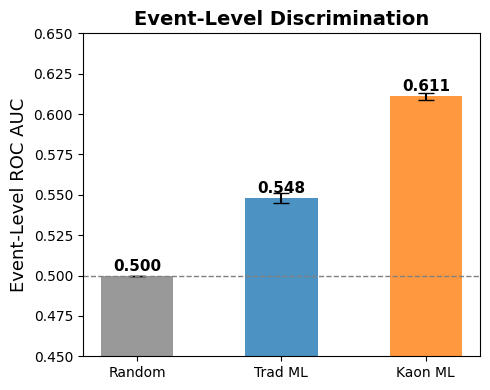

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
methods = ["Random", "Trad ML", "Kaon ML"]
rocs    = [0.500,    0.548,     0.611]
errors  = [0.000,    0.003,     0.002]  # from bootstrap CI widths
colors  = ["gray",   "tab:blue", "tab:orange"]
bars = ax.bar(methods, rocs, yerr=errors, capsize=6,color=colors, alpha=0.8, width=0.5)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_ylabel("Event-Level ROC AUC", fontsize=13)
ax.set_title("Event-Level Discrimination", fontsize=14, fontweight="bold")
ax.set_ylim(0.45, 0.65)
for bar, v in zip(bars, rocs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003,f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("poster_event_bar.pdf", dpi=150, bbox_inches="tight")

In [37]:

def efficiency_at_rejection(y_true, p_score, target_rej):
    fpr, tpr, _ = roc_curve(y_true, p_score)
    target_fpr = 1.0 / target_rej
    valid = np.where(fpr <= target_fpr)[0]
    return tpr[valid].max() if len(valid) else np.nan


In [40]:
def efficiency_at_rejection(y_true, p_score, target_rej):
    fpr, tpr, _ = roc_curve(y_true, p_score)
    target_fpr = 1.0 / target_rej
    if fpr.max() < target_fpr:
        return tpr.max()
    if fpr.min() > target_fpr:
        return np.nan
    return float(np.interp(target_fpr, fpr, tpr))

target_rej = [10, 100, 1000]
methods = [("Kaon ML (track)",oof_y_kaon, oof_p_kaon),("Trad ML (track)", oof_y_trad, oof_p_trad),("Cut-based (track)",oof_y_kaon, cut_oof),(f"Kaon ML (event/{best_kaon})",y_evt_kaon, p_evt_kaon),(f"Trad ML (event/{best_trad})",y_evt_trad, p_evt_trad),]

#background rejection as percentage
print("\nSignal efficiency at fixed background rejection")
print(f"{'Method':<32} "+"  ".join(f"{(1 - 1/r)*100:>5.1f}%"for r in target_rej))
print("-" *10 )
for name, y, p in methods:
    cells = []
    for r in target_rej:
        e = efficiency_at_rejection(y, p, r)
        cells.append(f"{e*100:>5.1f}%"if not np.isnan(e) else f"{'—':>6}")
    print(f"{name:<32} "+ "  ".join(cells))


Signal efficiency at fixed background rejection
Method                            90.0%   99.0%   99.9%
----------


Kaon ML (track)                   72.4%   18.3%    3.2%
Trad ML (track)                   22.4%    3.7%    0.6%
Cut-based (track)                 48.8%    4.9%    0.5%
Kaon ML (event/sum_norm)          18.9%    2.5%    0.4%
Trad ML (event/top3_sum)          13.6%    1.6%    0.2%


In [39]:
# Event paired t -test summary of results 
sgkf_evt = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
evt_fold_roc_trad, evt_fold_pr_trad = [], []
evt_fold_roc_kaon, evt_fold_pr_kaon = [], []

for _, te_idx in sgkf_evt.split(X, y_kaon, groups=groups):
    te_groups = set(groups[te_idx])
    for (oof_y, oof_p, oof_g, fold_roc_list, fold_pr_list, best_strat) in [(oof_y_trad, oof_p_trad, oof_g_trad,evt_fold_roc_trad, evt_fold_pr_trad, best_trad),  (oof_y_kaon, oof_p_kaon, oof_g_kaon, evt_fold_roc_kaon, evt_fold_pr_kaon, best_kaon),]:
        mask = np.isin(oof_g, list(te_groups))
        strats_fold = event_aggregate(oof_y[mask], oof_p[mask], oof_g[mask])
        ye, pe = strats_fold[best_strat]
        if len(np.unique(ye)) < 2:
            continue
        fold_roc_list.append(roc_auc_score(ye, pe))
        fold_pr_list.append(average_precision_score(ye, pe))
evt_fold_roc_trad = np.array(evt_fold_roc_trad)
evt_fold_pr_trad = np.array(evt_fold_pr_trad)
evt_fold_roc_kaon = np.array(evt_fold_roc_kaon)
evt_fold_pr_kaon= np.array(evt_fold_pr_kaon)
t_roc_e, p_roc_e= stats.ttest_rel(evt_fold_roc_kaon, evt_fold_roc_trad)
t_pr_e,  p_pr_e = stats.ttest_rel(evt_fold_pr_kaon,  evt_fold_pr_trad)

print("\n Paired t-test EVENT level")
print(f"ROC AUC: t={t_roc_e:.3f}, p={p_roc_e:.4f}  "f"{'significant' if p_roc_e < 0.05 else 'not significant'} at α=0.05")
print(f"PR  AUC: t={t_pr_e:.3f},  p={p_pr_e:.4f}  "f"{' significant' if p_pr_e  < 0.05 else ' not significant'} at α=0.05")
print(f"\n  Per-fold event ROC — Trad: {evt_fold_roc_trad.round(4)}  "f"mean={evt_fold_roc_trad.mean():.4f}")
print(f"Per-fold event ROC — Kaon: {evt_fold_roc_kaon.round(4)} "f"mean={evt_fold_roc_kaon.mean():.4f}")
print(f"Per-fold event PR — Trad: {evt_fold_pr_trad.round(4)} " f"mean={evt_fold_pr_trad.mean():.4f}")
print(f" Per-fold event PR — Kaon: {evt_fold_pr_kaon.round(4)} "f"mean={evt_fold_pr_kaon.mean():.4f}")


#The Kaon ML classifier achieves a background rejection of X at 90% signal efficiency, compared to Y for the cut-based selection, representing a Z-fold improvement


 Paired t-test EVENT level
ROC AUC: t=57.767, p=0.0000  significant at α=0.05
PR  AUC: t=-165.410,  p=0.0000   significant at α=0.05

  Per-fold event ROC — Trad: [0.5555 0.5519 0.5561 0.5576 0.5561]  mean=0.5554
Per-fold event ROC — Kaon: [0.6259 0.6232 0.6215 0.6297 0.6246] mean=0.6250
Per-fold event PR — Trad: [0.764  0.7638 0.7675 0.7656 0.766 ] mean=0.7653
 er-fold event PR — Kaon: [0.5046 0.5065 0.5035 0.511  0.5055] mean=0.5062
